In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error

In [2]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [7]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv")  # Load as a CSV file
df.to_csv("IMDB Dataset.csv", index=False)  # Save as a CSV file

In [8]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
# Check the data types of each column
print("Data Types:")
print(df.dtypes)

# Get the shape of the dataset (rows, columns)
print("\nShape of Dataset:")
print(df.shape)

Data Types:
review       object
sentiment    object
dtype: object

Shape of Dataset:
(50000, 2)


1.1 Loading the IMDB dataset using Keras


In [10]:
from tensorflow.keras.datasets import imdb

# Load the dataset
(num_words) = 10000  # Keep only the most common 10,000 words
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=num_words)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


1.2 Converting Sequences into Binary Matrices (One-Hot Encoding)
- Our model doesn't understand numbers as sequences. We need to convert them into a format it can learn from.

So we Convert each review into a vector where 1 means the word is present, and 0 means it's not.

In [12]:
import numpy as np

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))  # Create a matrix of zeros
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1  # Set 1 where words appear
    return results

# Convert train and test data
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Convert labels to float32 (needed for deep learning models)
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

# We transformed the list of word indices into a binary matrix.
# Now, each review is a vector of size 10,000 (each position is 1 if the word is in the review, 0 otherwise).
# Our labels (positive/negative) are now in a format the model can understand

1.3 Split the Data into Training and Validation Sets
We will take some data from our training set to use for validation.


- So we Create a validation set to check how well our model performs during training.


In [13]:
x_val = x_train[:10000]  # First 10,000 for validation
partial_x_train = x_train[10000:]  # Remaining for training

y_val = y_train[:10000]  # First 10,000 labels for validation
partial_y_train = y_train[10000:]  # Remaining labels for training

# We have set aside 10,000 reviews to validate our model while training.

Step 2: Build the Model
- We make a feedforward neural network with two hidden layers.
- We Use ReLU activation for the hidden layers.
- we Use Sigmoid activation for the output layer.

In [14]:
from tensorflow import keras
from tensorflow.keras import layers

# Define the model
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),  # First hidden layer
    layers.Dense(16, activation="relu"),  # Second hidden layer
    layers.Dense(1, activation="sigmoid")  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])


# We created a 3-layer neural network:
# 16 neurons in the first and second layers with ReLU activation.
# 1 neuron in the last layer with Sigmoid activation (because we need a probability between 0 and 1).
# We used RMSprop optimizer and binary cross-entropy loss (since it's a binary classification problem).

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Step 3. Train the Model
Now it's time to teach our model!

- To do that we Train for 20 epochs (20 rounds of learning).
- With a batch size of 512.
- We Monitor the validation set during training.


In [15]:
history = model.fit(partial_x_train, partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.6910 - loss: 0.6165 - val_accuracy: 0.8413 - val_loss: 0.4261
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8815 - loss: 0.3638 - val_accuracy: 0.8845 - val_loss: 0.3206
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9222 - loss: 0.2514 - val_accuracy: 0.8820 - val_loss: 0.2974
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9337 - loss: 0.2061 - val_accuracy: 0.8884 - val_loss: 0.2750
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9455 - loss: 0.1699 - val_accuracy: 0.8842 - val_loss: 0.2844
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9571 - loss: 0.1395 - val_accuracy: 0.8769 - val_loss: 0.3099
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9633 - loss: 0.1225 - val_accuracy: 0.8801 - val_loss: 0.2986
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9675 - loss: 0.1101 - val_accuracy: 0.8853 - 

Step 4: Evaluate the Model:

- We will now check how well our model is doing by plotting training and validation loss/accuracy.

We then use Matplotlib to visualize the learning curves

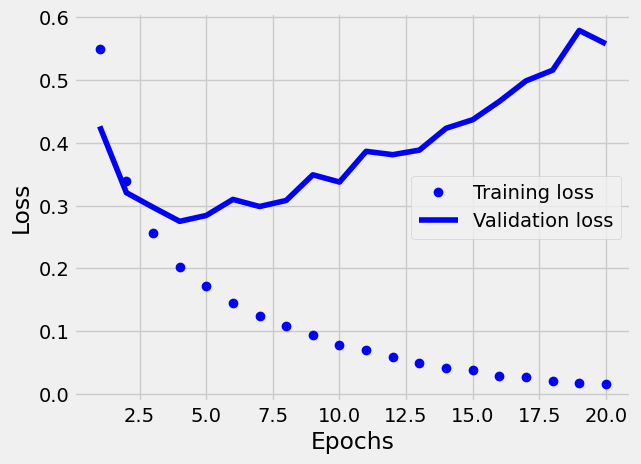

In [16]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)

# Plot loss
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

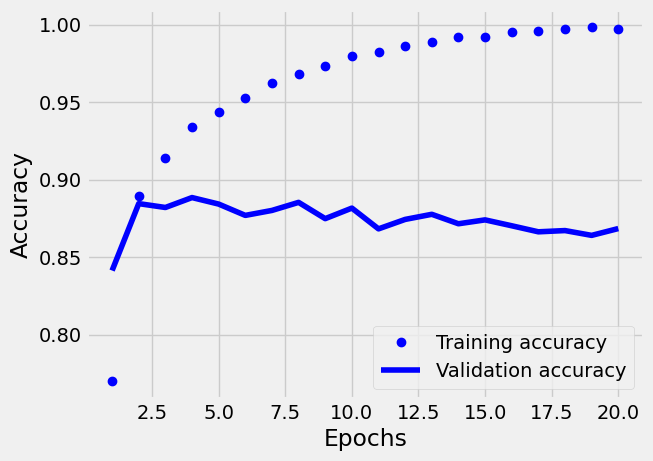

In [17]:
# Plot accuracy
plt.clf()
acc_values = history_dict["accuracy"]
val_acc_values = history_dict["val_accuracy"]

plt.plot(epochs, acc_values, "bo", label="Training accuracy")
plt.plot(epochs, val_acc_values, "b", label="Validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Observations from the Plots:

1. Loss Plot:

Training loss (dotted line) keeps decreasing, meaning the model is getting better at fitting the training data.
Validation loss (solid line) starts increasing after a few epochs, which means the model is not performing well on unseen data.

2. Accuracy Plot:

Training accuracy (dotted line) keeps increasing and reaches nearly 100%.
Validation accuracy (solid line) stays around 85-88% and does not improve.
This means the model is memorizing the training data but not generalizing well to new data.

- Conclusion: Overfitting Detected
The model is too specialized in the training data, and it struggles with new (validation) data.
This usually happens when the model is trained for too many epochs.


Step 5: Retrain with an Optimal Number of Epochs because of overfitting, we train again but with fewer epochs.

We choose the best epoch (e.g., 4 or 5) and retrain.

In [18]:
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.fit(partial_x_train, partial_y_train,
          epochs=4,  # Optimal number of epochs
          batch_size=512,
          validation_data=(x_val, y_val))

Epoch 1/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.7125 - loss: 0.5850 - val_accuracy: 0.8550 - val_loss: 0.4014
Epoch 2/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8927 - loss: 0.3420 - val_accuracy: 0.8821 - val_loss: 0.3156
Epoch 3/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9218 - loss: 0.2456 - val_accuracy: 0.8868 - val_loss: 0.2874
Epoch 4/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9405 - loss: 0.1930 - val_accuracy: 0.8842 - val_loss: 0.2890


In [19]:
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(10000,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.fit(partial_x_train, partial_y_train,
          epochs=4,  # Optimal number of epochs
          batch_size=512,
          validation_data=(x_val, y_val))

Epoch 1/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.6932 - loss: 0.6004 - val_accuracy: 0.8574 - val_loss: 0.4139
Epoch 2/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8867 - loss: 0.3523 - val_accuracy: 0.8860 - val_loss: 0.3158
Epoch 3/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9208 - loss: 0.2508 - val_accuracy: 0.8843 - val_loss: 0.2934
Epoch 4/4
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9359 - loss: 0.1981 - val_accuracy: 0.8890 - val_loss: 0.2789


Step 6: Evaluate the Final Model on Test Data
(To see how the model performs on unseen test data)

We test on x_test and y_test

In [20]:
results = model.evaluate(x_test, y_test)
print(f"Test Loss: {results[0]}")
print(f"Test Accuracy: {results[1]}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8801 - loss: 0.2940
Test Loss: 0.2944459319114685
Test Accuracy: 0.8815600275993347


The final accuracy is 88.01%, with a loss of 0.2940, which is pretty solid.

- Accuracy (88.01%): The model correctly classifies about 88% of the reviews.
- Loss (0.2940): Lower loss is better, meaning the model is making good predictions.

Conclusion
1. Preprocessed the data (Loaded, vectorized, split).
2. Built a neural network (2 hidden layers, ReLU, Sigmoid).
3. Trained the model (20 epochs, monitored validation).
4. Evaluated performance (Loss, accuracy, overfitting check).
5. Retrained optimally (Avoided overfitting).
6. Tested on real data.